In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Load the datasets
fraud_data = pd.read_csv('../data/Fraud_Data.csv')
creditcard_data = pd.read_csv('../data/creditcard.csv')
ip_data = pd.read_csv("../data/IpAddress_to_Country.csv")

# Display the first few rows of each dataset to understand the structure
display(fraud_data.head())
display(creditcard_data.head())

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check for missing values in Fraud_Data.csv
print("Missing values in Fraud_Data.csv:")
print(fraud_data.isnull().sum())

# Check for missing values in creditcard.csv
print("\nMissing values in creditcard.csv:")
print(creditcard_data.isnull().sum())

print("IP Data Missing Values:\n", ip_data.isnull().sum(), "\n")

Missing values in Fraud_Data.csv:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Missing values in creditcard.csv:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
IP Data Missing Values:
 lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64 



In [4]:
# Check for duplicates in Fraud_Data.csv
print("Duplicates in Fraud_Data.csv:", fraud_data.duplicated().sum())

# Remove duplicates if any
fraud_data.drop_duplicates(inplace=True)

# Check for duplicates in creditcard.csv
print("Duplicates in creditcard.csv:", creditcard_data.duplicated().sum())

print("Duplicates in ipAddress_to_Country.csv:", ip_data.duplicated().sum())
# Remove duplicates if any
creditcard_data.drop_duplicates(inplace=True)

Duplicates in Fraud_Data.csv: 0
Duplicates in creditcard.csv: 1081
Duplicates in ipAddress_to_Country.csv: 0


In [5]:
# Convert timestamp columns in Fraud_Data.csv to datetime
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'], errors='coerce')
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'], errors='coerce')

# Ensure 'class' column is an integer (0 or 1)
fraud_data['class'] = fraud_data['class'].astype(int)

# Convert 'Time' column in creditcard.csv to datetime (if needed)
# Note: 'Time' is in seconds elapsed, so it may not need conversion unless specified otherwise
creditcard_data['Time'] = creditcard_data['Time'].astype(float)

# Ensure 'Class' column in creditcard.csv is an integer (0 or 1)
creditcard_data['Class'] = creditcard_data['Class'].astype(int)

In [6]:
print("Data types in Fraud_Data.csv:")
print(fraud_data.dtypes)

print("\nData types in creditcard.csv:")
print(creditcard_data.dtypes)

print("ipAddress_to_Country")
print(ip_data.dtypes)

Data types in Fraud_Data.csv:
user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                    object
browser                   object
sex                       object
age                        int64
ip_address               float64
class                      int64
dtype: object

Data types in creditcard.csv:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtyp

In [7]:
# Load the IP address mapping dataset
ip_address_data = pd.read_csv('../data/IpAddress_to_Country.csv')

# Convert IP address bounds to integers
ip_address_data['lower_bound_ip_address'] = ip_address_data['lower_bound_ip_address'].astype(int)
ip_address_data['upper_bound_ip_address'] = ip_address_data['upper_bound_ip_address'].astype(int)

# Ensure country is a string
ip_address_data['country'] = ip_address_data['country'].astype(str)

# Check for duplicates in IP address data
print("Duplicates in IpAddress_to_Country.csv:", ip_address_data.duplicated().sum())

# Remove duplicates if any
ip_address_data.drop_duplicates(inplace=True)

# Verify data types in IP address data
print("\nData types in IpAddress_to_Country.csv:")
print(ip_address_data.dtypes)

Duplicates in IpAddress_to_Country.csv: 0

Data types in IpAddress_to_Country.csv:
lower_bound_ip_address     int64
upper_bound_ip_address     int64
country                   object
dtype: object


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of 'class' in Fraud_Data.csv
plt.figure(figsize=(8, 5))
sns.countplot(data=fraud_data, x='class', palette='coolwarm')
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions (Fraud_Data.csv)')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

C:\Users\Hp\AppData\Local\Temp\ipykernel_8212\2040622958.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=creditcard_data, x='Class', palette='coolwarm')


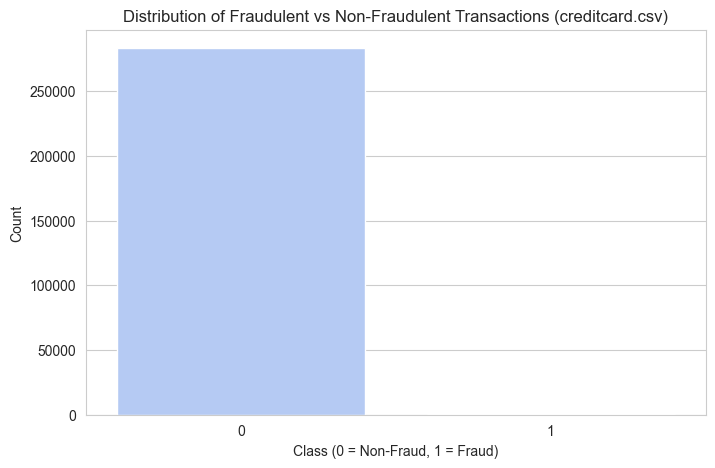

In [30]:
# Distribution of 'Class' in creditcard.csv
plt.figure(figsize=(8, 5))
sns.countplot(data=creditcard_data, x='Class', palette='coolwarm')
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions (creditcard.csv)')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

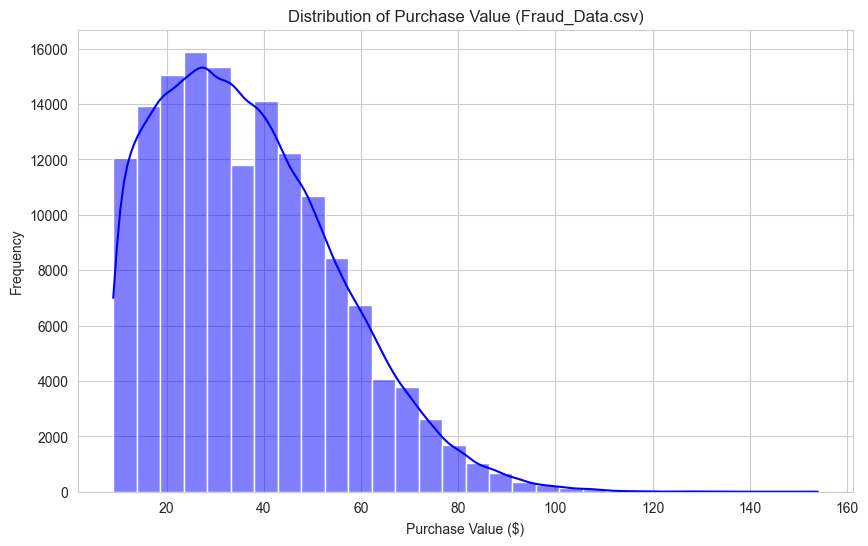

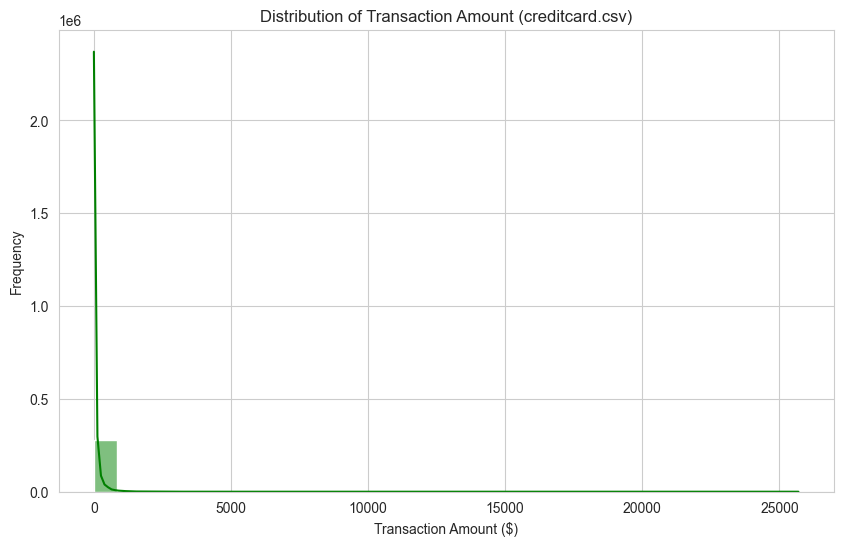

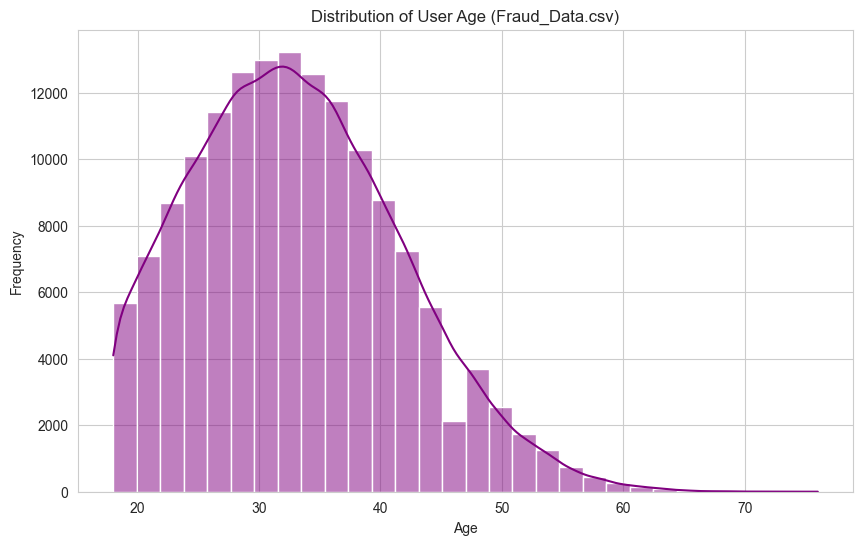

In [31]:
# Distribution of 'purchase_value' in Fraud_Data.csv
plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['purchase_value'], kde=True, bins=30, color='blue')
plt.title('Distribution of Purchase Value (Fraud_Data.csv)')
plt.xlabel('Purchase Value ($)')
plt.ylabel('Frequency')
plt.show()

# Distribution of 'Amount' in creditcard.csv
plt.figure(figsize=(10, 6))
sns.histplot(creditcard_data['Amount'], kde=True, bins=30, color='green')
plt.title('Distribution of Transaction Amount (creditcard.csv)')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency')
plt.show()

# Distribution of 'age' in Fraud_Data.csv
plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['age'], kde=True, bins=30, color='purple')
plt.title('Distribution of User Age (Fraud_Data.csv)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_8212\1537394384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x='source', palette='Set2')


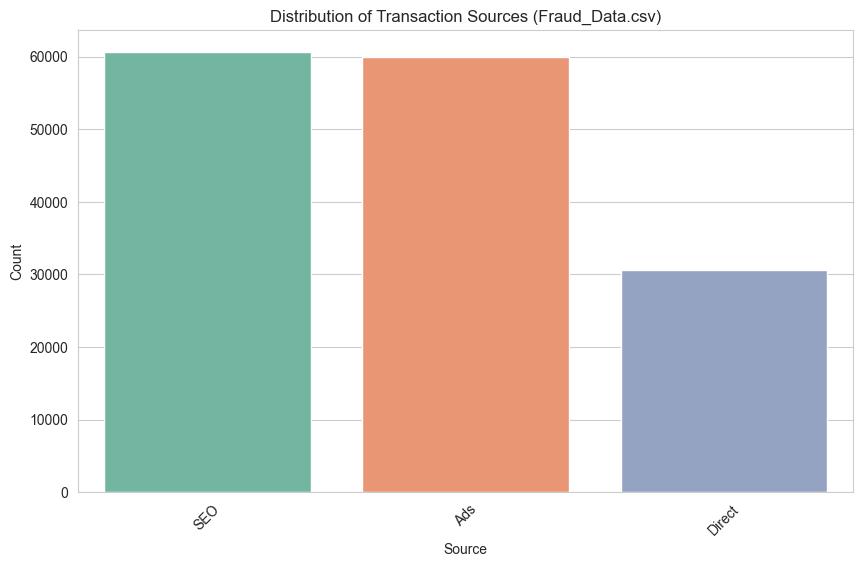

C:\Users\Hp\AppData\Local\Temp\ipykernel_8212\1537394384.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x='browser', palette='Set3')


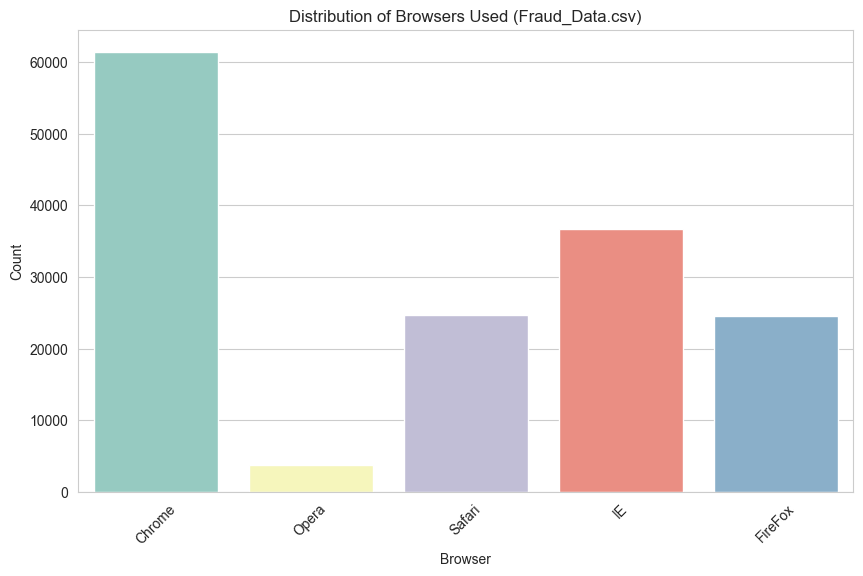

C:\Users\Hp\AppData\Local\Temp\ipykernel_8212\1537394384.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x='sex', palette='pastel')


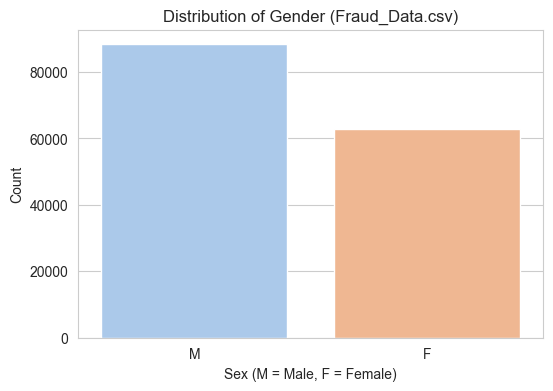

In [32]:
# Distribution of 'source' in Fraud_Data.csv
plt.figure(figsize=(10, 6))
sns.countplot(data=fraud_data, x='source', palette='Set2')
plt.title('Distribution of Transaction Sources (Fraud_Data.csv)')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Distribution of 'browser' in Fraud_Data.csv
plt.figure(figsize=(10, 6))
sns.countplot(data=fraud_data, x='browser', palette='Set3')
plt.title('Distribution of Browsers Used (Fraud_Data.csv)')
plt.xlabel('Browser')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Distribution of 'sex' in Fraud_Data.csv
plt.figure(figsize=(6, 4))
sns.countplot(data=fraud_data, x='sex', palette='pastel')
plt.title('Distribution of Gender (Fraud_Data.csv)')
plt.xlabel('Sex (M = Male, F = Female)')
plt.ylabel('Count')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_8212\2927771221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fraud_data, x='class', y='purchase_value', palette='viridis')


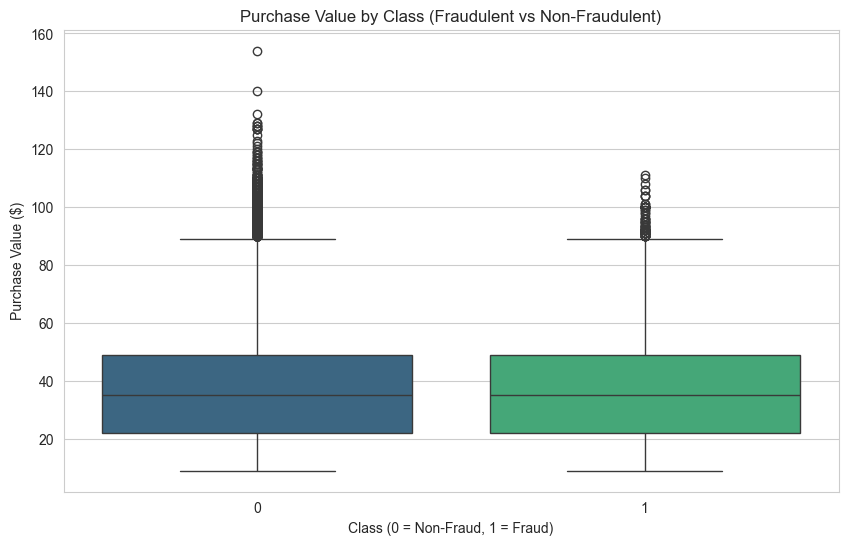

In [33]:
# Boxplot of 'purchase_value' by 'class'
plt.figure(figsize=(10, 6))
sns.boxplot(data=fraud_data, x='class', y='purchase_value', palette='viridis')
plt.title('Purchase Value by Class (Fraudulent vs Non-Fraudulent)')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Purchase Value ($)')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_8212\424073156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=creditcard_data, x='Class', y='Amount', palette='magma')


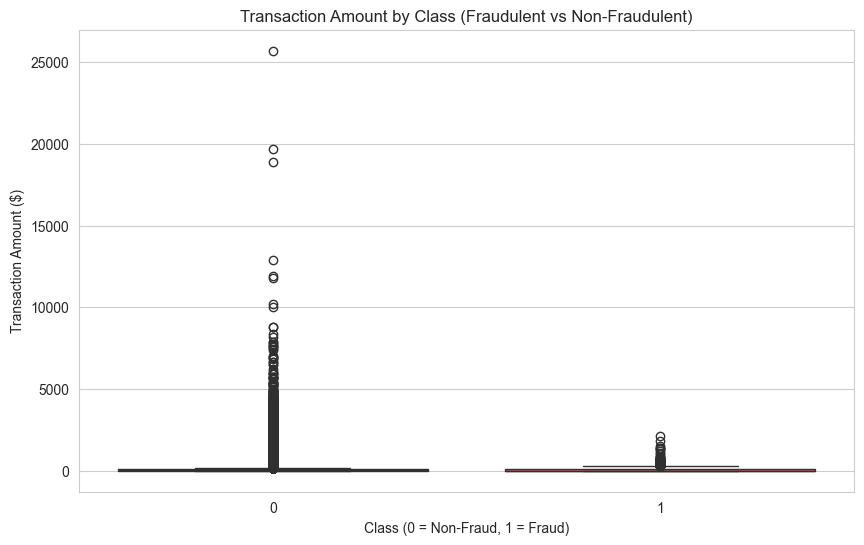

In [34]:
# Boxplot of 'Amount' by 'Class'
plt.figure(figsize=(10, 6))
sns.boxplot(data=creditcard_data, x='Class', y='Amount', palette='magma')
plt.title('Transaction Amount by Class (Fraudulent vs Non-Fraudulent)')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Transaction Amount ($)')
plt.show()

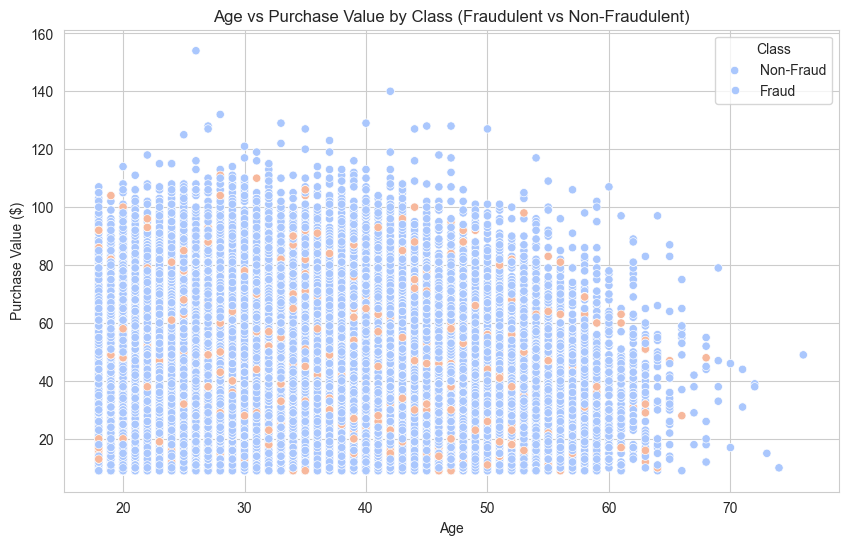

In [35]:
# Scatter plot of 'age' vs 'purchase_value' colored by 'class'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fraud_data, x='age', y='purchase_value', hue='class', palette='coolwarm')
plt.title('Age vs Purchase Value by Class (Fraudulent vs Non-Fraudulent)')
plt.xlabel('Age')
plt.ylabel('Purchase Value ($)')
plt.legend(title='Class', labels=['Non-Fraud', 'Fraud'])
plt.show()

In [12]:
# Load the datasets
fraud_data = pd.read_csv('../data/Fraud_Data.csv')
ip_address_data = pd.read_csv('../data/IpAddress_to_Country.csv')

# Inspect the first few rows of Fraud_Data.csv
print("First few rows of Fraud_Data.csv:")
display(fraud_data[['user_id', 'ip_address']].head())

# Inspect the first few rows of IpAddress_to_Country.csv
print("\nFirst few rows of IpAddress_to_Country.csv:")
display(ip_address_data.head())

First few rows of Fraud_Data.csv:


,user_id,ip_address
0,22058,7.327584e+08
1,333320,3.503114e+08
2,1359,2.621474e+09
3,150084,3.840542e+09
4,221365,4.155831e+08



First few rows of IpAddress_to_Country.csv:


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [9]:
def ip_to_int(ip):
    if pd.isnull(ip) or not isinstance(ip, str):  # Handle missing or non-string values
        return None
    try:
        octets = list(map(int, ip.split('.')))
        if len(octets) != 4:  # Ensure the IP address has exactly 4 octets
            return None
        return (octets[0] * 256**3) + (octets[1] * 256**2) + (octets[2] * 256) + octets[3]
    except Exception as e:
        print(f"Error processing IP address '{ip}': {e}")
        return None

In [32]:
# Calculate transaction frequency per user
user_frequency = fraud_data.groupby('user_id')['purchase_time'].count().reset_index()
user_frequency.rename(columns={'purchase_time': 'transaction_count'}, inplace=True)

# Merge back to the main dataset
fraud_data = fraud_data.merge(user_frequency, on='user_id', how='left')

# Display the first few rows to verify
display(fraud_data[['user_id', 'transaction_count']].head())

# Calculate time between consecutive transactions for each user
fraud_data = fraud_data.sort_values(by=['user_id', 'purchase_time']).reset_index(drop=True)
fraud_data['time_since_last_transaction'] = fraud_data.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

# Display the first few rows to verify
display(fraud_data[['user_id', 'purchase_time', 'time_since_last_transaction']].head())

,user_id,transaction_count
0,22058,1
1,333320,1
2,1359,1
3,150084,1
4,221365,1


,user_id,purchase_time,time_since_last_transaction
0,2,2015-02-21 10:03:37,NaN
1,4,2015-09-26 21:32:16,NaN
2,8,2015-08-13 11:53:07,NaN
3,9,2015-05-20 23:06:42,NaN
4,12,2015-03-04 20:56:37,NaN


In [33]:
# Merge fraud_data with user_frequency on 'user_id', using suffixes to handle duplicates
fraud_data = fraud_data.merge(
    user_frequency, 
    on='user_id', 
    how='left', 
    suffixes=('_fraud', '_freq')  # Add suffixes to differentiate columns
)

# Display the first few rows to verify
display(fraud_data[['user_id', 'transaction_count_freq']].head())

,user_id,transaction_count_freq
0,2,1
1,4,1
2,8,1
3,9,1
4,12,1


In [34]:
# Check the distribution of countries
print("Distribution of Countries:")
print(fraud_data['country'].value_counts())

# Check the number of transactions with unknown countries
unknown_count = fraud_data[fraud_data['country'] == 'Unknown'].shape[0]
print(f"\nNumber of transactions with unknown countries: {unknown_count}")

Distribution of Countries:
Series([], Name: count, dtype: int64)

Number of transactions with unknown countries: 0


In [35]:
# Display the column names in fraud_data
print("Columns in fraud_data:", fraud_data.columns.tolist())

Columns in fraud_data: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'ip_int', 'country', 'transaction_count_fraud', 'time_since_last_transaction', 'transaction_count_freq']


In [36]:
# One-hot encode categorical features
fraud_data = pd.get_dummies(fraud_data, columns=['source', 'browser', 'sex', 'country'], drop_first=True)

# Display the first few rows to verify
display(fraud_data.head())

,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,ip_int,transaction_count_fraud,time_since_last_transaction,transaction_count_freq,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M
0,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,25,880217484.812293,0,880217484.812293,1,NaN,1,False,True,False,False,False,False,False
1,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,38,2785906106.58509,0,2785906106.58509,1,NaN,1,True,False,False,False,False,True,False
2,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,25,356056736.628927,0,356056736.628927,1,NaN,1,False,True,False,False,False,False,True
3,9,2015-05-16 15:58:32,2015-05-20 23:06:42,62,IEZOHXPZBIRTE,21,759104706.486114,0,759104706.486114,1,NaN,1,False,True,True,False,False,False,True
4,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,19,2985180352.90002,0,2985180352.90002,1,NaN,1,False,False,False,False,False,True,True


In [46]:
# Install scikit-learn


import sklearn
from sklearn.preprocessing import MinMaxScaler

# Normalize numerical columns
scaler = MinMaxScaler()
numerical_cols = ['purchase_value', 'age', 'time_since_last_transaction']
fraud_data[numerical_cols] = scaler.fit_transform(fraud_data[numerical_cols])

c:\Users\Hp\Videos\fraudDetection1\fraudenv\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\Hp\Videos\fraudDetection1\fraudenv\Lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [47]:
# Display the column names in fraud_data
print("Columns in fraud_data:", fraud_data.columns.tolist())

Columns in fraud_data: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'age', 'ip_address', 'class', 'ip_int', 'transaction_count_fraud', 'time_since_last_transaction', 'transaction_count_freq', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M']


In [48]:
# Display the first few rows of the dataset to verify one-hot encoding
display(fraud_data.head())

# Check for existing one-hot encoded columns
print("One-hot encoded columns:")
encoded_columns = [col for col in fraud_data.columns if '_' in col]
print(encoded_columns)

,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,ip_int,transaction_count_fraud,time_since_last_transaction,transaction_count_freq,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M
0,2,2015-01-11 03:47:13,2015-02-21 10:03:37,0.310345,FGBQNDNBETFJJ,0.120690,880217484.812293,0,880217484.812293,1,NaN,1,False,True,False,False,False,False,False
1,4,2015-06-02 16:40:57,2015-09-26 21:32:16,0.220690,MKFUIVOHLJBYN,0.344828,2785906106.58509,0,2785906106.58509,1,NaN,1,True,False,False,False,False,True,False
2,8,2015-05-28 07:53:06,2015-08-13 11:53:07,0.262069,SCQGQALXBUQZJ,0.120690,356056736.628927,0,356056736.628927,1,NaN,1,False,True,False,False,False,False,True
3,9,2015-05-16 15:58:32,2015-05-20 23:06:42,0.365517,IEZOHXPZBIRTE,0.051724,759104706.486114,0,759104706.486114,1,NaN,1,False,True,True,False,False,False,True
4,12,2015-01-10 06:25:12,2015-03-04 20:56:37,0.179310,MSNWCFEHKTIOY,0.017241,2985180352.90002,0,2985180352.90002,1,NaN,1,False,False,False,False,False,True,True


One-hot encoded columns:
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'ip_address', 'ip_int', 'transaction_count_fraud', 'time_since_last_transaction', 'transaction_count_freq', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M']
